# EDA y preparación del modelo operativo

En esta notebook se trabajará con el conjunto reducido de variables seleccionado para construir un modelo operativo de informalidad laboral. El objetivo es analizar la calidad y distribución de estas variables, definir las recodificaciones necesarias y preparar una base consistente para el entrenamiento y evaluación de modelos.

El análisis se realizará sobre la población ocupada de 15 años o más de la ENOE del primer trimestre de 2026, utilizando `EMP_PPAL` como variable objetivo.


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sklearn as sk

In [84]:
df_operativo_v1 = pd.read_csv("/home/jeffrey/Documentos/Proyectos/enoe_informalidad/data/processed/df_operativo_v1.csv")

Vemos que la columna CVE_ENT se duplicó al utilizarla como variable predictora y ser parte de la llave. Veamos si tiene los mismos valores.

In [85]:
print(df_operativo_v1[["CVE_ENT", "CVE_ENT.1"]].head())
print((df_operativo_v1["CVE_ENT"] == df_operativo_v1["CVE_ENT.1"]).value_counts())

   CVE_ENT  CVE_ENT.1
0        9          9
1        9          9
2        9          9
3        9          9
4        9          9
True    187557
Name: count, dtype: int64


In [86]:
df_operativo_v1 = df_operativo_v1.drop(columns="CVE_ENT.1")

In [87]:
llave = ["TIPO","MES_CAL","CD_A", "CVE_ENT", "CON", "V_SEL", "N_HOG", "H_MUD", "N_REN"]
var_objetivo = ["EMP_PPAL"]
var_trazabilidad = ["FAC_TRI", "FAC_MEN"]

In [88]:
variables = list(set(df_operativo_v1.columns) - set(llave + var_objetivo + var_trazabilidad)) + ["CVE_ENT"]

X = df_operativo_v1[variables].copy()
y = df_operativo_v1["EMP_PPAL"].copy()
pesos = df_operativo_v1["FAC_TRI"].copy()

Revicemos su forma, tipo de datos, duplicados y valores únicos de las 12 variables predictoras

In [89]:
print("Numero de registros:", X.shape[0],"numero de columnas:", X.shape[1])
print(X.dtypes)


Numero de registros: 187557 numero de columnas: 12
SEX          int64
P3R_ANIO     int64
P3A          int64
E_CON        int64
DUR_EST      int64
EDA          int64
T_LOC_TRI    int64
PAR_C        int64
BUSCAR5C     int64
ING7C        int64
CS_P13_1     int64
CVE_ENT      int64
dtype: object


Contemos cuántos perfiles duplicados existen

In [90]:
print("Perfiles duplicados:", X.duplicated().sum())

Perfiles duplicados: 2631


Veamos un resumen con los tipos de datos

In [91]:
for col in X.columns:
    print(
        col,
        "| únicos:", X[col].nunique(),
        "| valores:", sorted(X[col].unique())[:20]
    )

SEX | únicos: 2 | valores: [np.int64(1), np.int64(2)]
P3R_ANIO | únicos: 79 | valores: [np.int64(1940), np.int64(1942), np.int64(1946), np.int64(1950), np.int64(1953), np.int64(1954), np.int64(1955), np.int64(1956), np.int64(1957), np.int64(1958), np.int64(1959), np.int64(1960), np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964), np.int64(1965), np.int64(1966), np.int64(1967), np.int64(1968)]
P3A | únicos: 2 | valores: [np.int64(1), np.int64(2)]
E_CON | únicos: 7 | valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9)]
DUR_EST | únicos: 6 | valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
EDA | únicos: 82 | valores: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34)

Veamos la distribución de las columnas

In [92]:
for col in X.columns:
    # print(f"\n{col}")
    print(X[col].value_counts(dropna=False).sort_index())

SEX
1    109441
2     78116
Name: count, dtype: int64
P3R_ANIO
1940        1
1942        1
1946        1
1950        5
1953        1
        ...  
2023    17778
2024    20981
2025    26786
2026     7577
9999     1722
Name: count, Length: 79, dtype: int64
P3A
1    137815
2     49742
Name: count, dtype: int64
E_CON
1    38964
2    11337
3     5269
4     5438
5    68189
6    58338
9       22
Name: count, dtype: int64
DUR_EST
1     6188
2    12396
3    33021
4    90892
5    42886
6     2174
Name: count, dtype: int64
EDA
15     809
16    1188
17    1545
18    2425
19    2695
      ... 
92       7
93       5
94       5
95       5
97       4
Name: count, Length: 82, dtype: int64
T_LOC_TRI
1    108931
2     24893
3     24722
4     29011
Name: count, dtype: int64
PAR_C
101    86543
201    27973
202     6636
203       28
301    48326
302      317
303      875
304       52
401      910
402       45
403     3176
404       26
405       11
406       21
408     3498
409       59
410       55
411     

La documentación menciona que PAR_C tiene códigos muy específicos para cada parentesco. Nosotros lo agruparemos en ciertas categorías

In [93]:
def agrupar_parentesco(codigo):
    if codigo == 101:
        return "jefe_hogar"
    elif codigo in [201, 202, 203]:
        return "pareja"
    elif codigo in [301, 302, 303, 304]:
        return "hijo"
    elif 401 <= codigo <= 424:
        return "otro_familiar"
    elif codigo in [501, 502, 503, 701]:
        return "no_familiar_otro"
    elif codigo in [601, 611, 612, 613]:
        return "trabajo_domestico_familia"
    elif codigo == 999:
        return "no_especificado"
    else:
        return "otro"

X["PAR_C_GRUPO"] = X["PAR_C"].apply(agrupar_parentesco)

Verifiquemos como quedó cada grupo

In [94]:
X["PAR_C_GRUPO"].value_counts(dropna=False)

PAR_C_GRUPO
jefe_hogar                   86543
hijo                         49570
pareja                       34637
otro_familiar                15530
no_familiar_otro              1071
trabajo_domestico_familia      138
no_especificado                 68
Name: count, dtype: int64

Correcto. Eliminemos PAR_C

In [95]:
X.drop(columns="PAR_C",inplace=True)

Ahora transformemos P3R_ANIO. Esta variable indica el año en el que empezó a trabajar. Nosotros la trataremos como antiguedad del trabajo.

In [96]:
# Transforma de un año específico a la diferencia actual (2026)
X["ANTIGUEDAD"] = 2026 - X["P3R_ANIO"]
X.loc[X["P3R_ANIO"] == 9999, "ANTIGUEDAD"] = pd.NA



In [97]:
# Los agrupa en grupos específicos
bins = [-1, 0, 2, 5, 10, 20, float("inf")]
labels = [
    "Menos de 1 año",
    "1 a 2 años",
    "3 a 5 años",
    "6 a 10 años",
    "11 a 20 años",
    "Más de 20 años"
]

X["ANTIGUEDAD_GRUPO"] = pd.cut(
    X["ANTIGUEDAD"],
    bins=bins,
    labels=labels
)

X["ANTIGUEDAD_GRUPO"] = (
    X["ANTIGUEDAD_GRUPO"]
    .cat.add_categories("No sabe")
    .fillna("No sabe")
)

In [98]:
print(X["ANTIGUEDAD"].describe())
print()
print(X["ANTIGUEDAD_GRUPO"].value_counts(dropna=False))
print()
print("Casos no sabe:", (X["P3R_ANIO"] == 9999).sum())
print("Antigüedades negativas:", (X["ANTIGUEDAD"] < 0).sum())

count    185835.000000
mean          8.935620
std           9.935162
min           0.000000
25%           2.000000
50%           5.000000
75%          11.000000
max          86.000000
Name: ANTIGUEDAD, dtype: float64

ANTIGUEDAD_GRUPO
1 a 2 años        47767
3 a 5 años        41313
6 a 10 años       34660
11 a 20 años      29318
Más de 20 años    25200
Menos de 1 año     7577
No sabe            1722
Name: count, dtype: int64

Casos no sabe: 1722
Antigüedades negativas: 0


In [99]:
X.drop(columns="P3R_ANIO",inplace=True)

En principio utilizaremos la antiguedad como variable. Su agrupación quedará para un análisis posterior.

Ahora analicemos CS_P13_1. Este indica el nivel escolar del entrevistado, con codigos válidos del 00 al 09 y 99 para los que no saben.

In [100]:
X["CS_P13_1"].value_counts(dropna=False)

CS_P13_1
3     50558
7     48186
4     46763
2     27522
6      5116
0      3967
8      3955
9       753
99      456
5       188
1        93
Name: count, dtype: int64

Posiblemente los valores fueron convertidos a numéricos al guardarlos como csv

In [101]:
X["CS_P13_1"].dtype

dtype('int64')

Se mapeará de la siguiente manera

In [102]:
mapa_escolaridad = {
    0: "sin_escolaridad",
    1: "preescolar",
    2: "primaria",
    3: "secundaria",
    4: "media_superior",
    5: "normal_tecnica",
    6: "normal_tecnica",
    7: "profesional",
    8: "posgrado",
    9: "posgrado",
    99: "no_sabe"
}

X["ESCOLARIDAD_GRUPO"] = X["CS_P13_1"].map(mapa_escolaridad)
X = X.drop(columns="CS_P13_1")
X["ESCOLARIDAD_GRUPO"].value_counts(dropna=False)

ESCOLARIDAD_GRUPO
secundaria         50558
profesional        48186
media_superior     46763
primaria           27522
normal_tecnica      5304
posgrado            4708
sin_escolaridad     3967
no_sabe              456
preescolar            93
Name: count, dtype: int64

Ahora, revisemos la variable ING7C, que corresponde a la clasificación por nivel de ingreso. Según la documentación:

+ 1 Hasta un salario mínimo
+ 2 Más de 1 hasta 2 salarios mínimos
+ 3 Más de 2 hasta 3 salarios mínimos
+ 4 Más de 3 hasta 5 salarios mínimos
+ 5 Más de 5 salarios mínimos
+ 6 No recibe ingresos
+ 7 No especificado

In [103]:
X["ING7C"].value_counts(dropna=False)

ING7C
1    85824
2    59103
7    18531
3    11463
6     7085
4     4272
5     1279
Name: count, dtype: int64

Entonces, 
+ 1–5 sí representan rangos crecientes de ingreso.
+ 6 significa “no recibe ingresos”.
+ 7 significa “no especificado”.

El mapeo será el siguiente. De esta manera, al usarlas como categóricas, evitamos imponer que sin_ingresos o no_especificado estén "por encima" de los demás rangos.

In [104]:
mapa_ingreso = {
    1: "hasta_1_sm",
    2: "mas_1_hasta_2_sm",
    3: "mas_2_hasta_3_sm",
    4: "mas_3_hasta_5_sm",
    5: "mas_5_sm",
    6: "sin_ingresos",
    7: "no_especificado"
}

X["INGRESO_GRUPO"] = X["ING7C"].map(mapa_ingreso)
X = X.drop(columns="ING7C")
X["INGRESO_GRUPO"].value_counts(dropna=False)

INGRESO_GRUPO
hasta_1_sm          85824
mas_1_hasta_2_sm    59103
no_especificado     18531
mas_2_hasta_3_sm    11463
sin_ingresos         7085
mas_3_hasta_5_sm     4272
mas_5_sm             1279
Name: count, dtype: int64

`no_especificado` representa 18,531 casos, casi 10% de la muestra. No conviene tratarlo como faltante ni eliminarlo. Se mantendrá como categoría porque su ausencia de información puede tener señal propia.

Ahora veamos DUR_EST. Según la documentación, esta variable representa la clasificación de la población ocupara por duración de la jornada. 

1 Ausentes temporales con vínculo laboral
2 Menos de 15 horas
3 De 15 a 34 horas
4 De 35 a 48 horas
5 Más de 48 horas
6 No especificado

Veamos

In [105]:
X["DUR_EST"].value_counts(dropna=False)

DUR_EST
4    90892
5    42886
3    33021
2    12396
1     6188
6     2174
Name: count, dtype: int64

También tiene un orden natural para los códigos 2–5, pero 1 y 6 son categorías especiales. Por eso conviene tratarla como categórica etiquetada, no como número ordinal directo.

In [106]:
mapa_duracion = {
    1: "ausente_con_vinculo",
    2: "menos_15_horas",
    3: "15_a_34_horas",
    4: "35_a_48_horas",
    5: "mas_48_horas",
    6: "no_especificado"
}

X["DURACION_GRUPO"] = X["DUR_EST"].map(mapa_duracion)
X = X.drop(columns="DUR_EST")

X["DURACION_GRUPO"].value_counts(dropna=False)

DURACION_GRUPO
35_a_48_horas          90892
mas_48_horas           42886
15_a_34_horas          33021
menos_15_horas         12396
ausente_con_vinculo     6188
no_especificado         2174
Name: count, dtype: int64

Ahora analicemos T_LOC_TRI, la cuál representa el tamaño de la localidad trimestral, con valores

+ 1 Localidades mayores de 100 000 habitantes
+ 2 Localidades de 15 000 a 99 999 habitantes
+ 3 Localidades de 2 500 a 14 999 habitantes
+ 4 Localidades menores de 2 500 habitantes

Veamos

In [107]:
X["T_LOC_TRI"].value_counts()

T_LOC_TRI
1    108931
4     29011
2     24893
3     24722
Name: count, dtype: int64

Conforme aumenta el código, disminuye el tamaño de la localidad. Aun así, para el primer modelo la trataremos como categórica etiquetada de la siguiente forma

In [108]:
mapa_localidad = {
    1: "mas_100_mil",
    2: "15_mil_a_99_999",
    3: "2_500_a_14_999",
    4: "menos_2_500"
}

X["TAMANO_LOCALIDAD"] = X["T_LOC_TRI"].map(mapa_localidad)

X = X.drop(columns="T_LOC_TRI")
X["TAMANO_LOCALIDAD"].value_counts(dropna=False)

TAMANO_LOCALIDAD
mas_100_mil        108931
menos_2_500         29011
15_mil_a_99_999     24893
2_500_a_14_999      24722
Name: count, dtype: int64

Revisemos ahora E_CON: estado conyugal, con valores

+ 1 Vive con su pareja en unión libre
+ 2 Está separado(a)
+ 3 Está divorciado(a)
+ 4 Está viudo(a)
+ 5 Está casado(a)
+ 6 Está soltero(a)
+ 9 No sabe

In [109]:
X["E_CON"].value_counts(dropna=False)

E_CON
5    68189
6    58338
1    38964
2    11337
4     5438
3     5269
9       22
Name: count, dtype: int64

Esta la mantendremos así pero cambiando etiquetas para mejorar interpretabilidad.


In [110]:
mapa_estado_conyugal = {
    1: "union_libre",
    2: "separado",
    3: "divorciado",
    4: "viudo",
    5: "casado",
    6: "soltero",
    9: "no_sabe"
}

X["ESTADO_CONYUGAL"] = X["E_CON"].map(mapa_estado_conyugal)

X = X.drop(columns="E_CON")
X["ESTADO_CONYUGAL"].value_counts(dropna=False)

ESTADO_CONYUGAL
casado         68189
soltero        58338
union_libre    38964
separado       11337
viudo           5438
divorciado      5269
no_sabe           22
Name: count, dtype: int64

Ahora revisemos BUSCAR5C, la cual corresponde a la clasificación de la población ocupara por búsqueda de otro empleo

+ 1 Para tener otro empleo
+ 2 Para cambiarse de trabajo
+ 3 Otro
+ 4 No buscó
+ 5 No especificado

In [111]:
X["BUSCAR5C"].value_counts()

BUSCAR5C
4    182060
2      3379
1      1086
3       946
5        86
Name: count, dtype: int64

Dado el fuerte desbalance, no conseremos las cinco categorías para la primera versión. Usaremos esta otra clasificación


In [112]:
mapa_busqueda = {
    1: "busco_otro_empleo",
    2: "busco_otro_empleo",
    3: "busco_otro_empleo",
    4: "no_busco",
    5: "no_especificado"
}

X["BUSQUEDA_OTRO_EMPLEO"] = X["BUSCAR5C"].map(mapa_busqueda)

X = X.drop(columns="BUSCAR5C")
X["BUSQUEDA_OTRO_EMPLEO"].value_counts(dropna=False)

BUSQUEDA_OTRO_EMPLEO
no_busco             182060
busco_otro_empleo      5411
no_especificado          86
Name: count, dtype: int64

La categoría busco_otro_empleo representa cerca de 2.9% de la muestra, así que sigue siendo minoritaria pero suficientemente grande para conservarla. no_especificado debe mantenerse separado por ahora.

Revisemos ahora P3A: ¿En su trabajo ... tiene un jefe(a) o superior?, con valores

+ 1 Sí
+ 2 No

Veamos

In [113]:
X["P3A"].value_counts(dropna=False)

P3A
1    137815
2     49742
Name: count, dtype: int64

P3A ya es binaria, tiene cobertura completa y no requiere agrupación. Solo conviene reemplazar los códigos por etiquetas para el EDA

In [114]:
mapa_jefe = {
    1: "si",
    2: "no"
}

X["TIENE_JEFE"] = X["P3A"].map(mapa_jefe)

X = X.drop(columns="P3A")
X["TIENE_JEFE"].value_counts(dropna=False)

TIENE_JEFE
si    137815
no     49742
Name: count, dtype: int64

Ahora veamos SEX, que representa el sexo de la persona, con valores
+ 1 Hombre
+ 2 Mujer

In [115]:
X["SEX"].value_counts(dropna=False)

SEX
1    109441
2     78116
Name: count, dtype: int64

Solo recodifiquemos con etiquetas para interpretabilidad

In [116]:
mapa_sexo = {
    1: "hombre",
    2: "mujer"
}

X["SEXO"] = X["SEX"].map(mapa_sexo)

X = X.drop(columns="SEX")
X["SEXO"].value_counts(dropna=False)

SEXO
hombre    109441
mujer      78116
Name: count, dtype: int64

Ahora comprobemos CVE_ENT, que representa la clave de la entidad. Se recomienda revisar la documentación para identificar sus valores.

In [117]:
X["CVE_ENT"].value_counts()

CVE_ENT
7     8502
15    7715
30    7603
2     7226
11    7225
4     7216
5     7212
28    6910
21    6788
8     6786
20    6290
10    6020
19    5895
14    5860
18    5816
31    5533
29    5446
16    5430
22    5310
6     5148
12    5090
27    5085
25    5071
24    4978
17    4906
26    4857
1     4796
9     4780
32    4741
13    4586
23    4565
3     4171
Name: count, dtype: int64

No se observan categorías demasiado pequeñas. Conviene mapear los códigos a nombres y mantenerla como variable categórica nominal

In [118]:
mapa_entidad = {
    1: "Aguascalientes",
    2: "Baja California",
    3: "Baja California Sur",
    4: "Campeche",
    5: "Coahuila",
    6: "Colima",
    7: "Chiapas",
    8: "Chihuahua",
    9: "Ciudad de México",
    10: "Durango",
    11: "Guanajuato",
    12: "Guerrero",
    13: "Hidalgo",
    14: "Jalisco",
    15: "México",
    16: "Michoacán",
    17: "Morelos",
    18: "Nayarit",
    19: "Nuevo León",
    20: "Oaxaca",
    21: "Puebla",
    22: "Querétaro",
    23: "Quintana Roo",
    24: "San Luis Potosí",
    25: "Sinaloa",
    26: "Sonora",
    27: "Tabasco",
    28: "Tamaulipas",
    29: "Tlaxcala",
    30: "Veracruz",
    31: "Yucatán",
    32: "Zacatecas"
}

X["ENTIDAD"] = X["CVE_ENT"].map(mapa_entidad)

X = X.drop(columns="CVE_ENT")
X["ENTIDAD"].value_counts(dropna=False)

ENTIDAD
Chiapas                8502
México                 7715
Veracruz               7603
Baja California        7226
Guanajuato             7225
Campeche               7216
Coahuila               7212
Tamaulipas             6910
Puebla                 6788
Chihuahua              6786
Oaxaca                 6290
Durango                6020
Nuevo León             5895
Jalisco                5860
Nayarit                5816
Yucatán                5533
Tlaxcala               5446
Michoacán              5430
Querétaro              5310
Colima                 5148
Guerrero               5090
Tabasco                5085
Sinaloa                5071
San Luis Potosí        4978
Morelos                4906
Sonora                 4857
Aguascalientes         4796
Ciudad de México       4780
Zacatecas              4741
Hidalgo                4586
Quintana Roo           4565
Baja California Sur    4171
Name: count, dtype: int64

Ahora solo falta EDA, que es la edad del entrevistado.

In [119]:
X["EDA"].value_counts()

EDA
30    4757
25    4643
31    4593
33    4576
36    4557
      ... 
92       7
93       5
95       5
94       5
97       4
Name: count, Length: 82, dtype: int64

La conservaremos como variable numérica continua para modelado y crearemos una versión agrupada únicamente para el EDA.

In [120]:
bins = [14, 24, 34, 44, 54, 64, 97]
labels = [
    "15_a_24",
    "25_a_34",
    "35_a_44",
    "45_a_54",
    "55_a_64",
    "65_y_mas"
]

X["EDAD_GRUPO"] = pd.cut(
    X["EDA"],
    bins=bins,
    labels=labels
)
X["EDAD_GRUPO"].value_counts(dropna=False).sort_index()

EDAD_GRUPO
15_a_24     26768
25_a_34     43803
35_a_44     43589
45_a_54     39067
55_a_64     24026
65_y_mas    10304
Name: count, dtype: int64

Con esto terminamos la recodificación de las 12 variables. Validemos ahora la estructura final de X

In [121]:
print("Forma:", X.shape)
print("\nTipos:")
print(X.dtypes)
print("\nNulos por columna:")
print(X.isna().sum())
print("\nColumnas:")
print(X.columns.tolist())

Forma: (187557, 14)

Tipos:
EDA                        int64
PAR_C_GRUPO               object
ANTIGUEDAD               float64
ANTIGUEDAD_GRUPO        category
ESCOLARIDAD_GRUPO         object
INGRESO_GRUPO             object
DURACION_GRUPO            object
TAMANO_LOCALIDAD          object
ESTADO_CONYUGAL           object
BUSQUEDA_OTRO_EMPLEO      object
TIENE_JEFE                object
SEXO                      object
ENTIDAD                   object
EDAD_GRUPO              category
dtype: object

Nulos por columna:
EDA                        0
PAR_C_GRUPO                0
ANTIGUEDAD              1722
ANTIGUEDAD_GRUPO           0
ESCOLARIDAD_GRUPO          0
INGRESO_GRUPO              0
DURACION_GRUPO             0
TAMANO_LOCALIDAD           0
ESTADO_CONYUGAL            0
BUSQUEDA_OTRO_EMPLEO       0
TIENE_JEFE                 0
SEXO                       0
ENTIDAD                    0
EDAD_GRUPO                 0
dtype: int64

Columnas:
['EDA', 'PAR_C_GRUPO', 'ANTIGUEDAD', 'ANTIGUED

Los 1,722 nulos de `ANTIGUEDAD` corresponden a `P3R_ANIO=9999` ("No sabe").

Mantengamos presente que X contiene dos pares redundantes para fines distintos
+ Modelado: `EDA` y posiblemente `ANTIGUEDAD`
+ EDA: `EDAD_GRUPO` y `ANTIGUEDAD_GRUPO`

Por ahora conservaremos las 14 columnas. Lo siguiente que haremos es unir temporalmente `X` con `y` y `FAC_TRI`para comenzar el EDA bivariado contra `EMP_PPAL`

In [122]:
df_eda = X.copy()
df_eda["EMP_PPAL"] = y.values
df_eda["FAC_TRI"] = pesos.values

print(df_eda.shape)
print(df_eda[["EMP_PPAL", "FAC_TRI"]].head())
print(df_eda["EMP_PPAL"].value_counts())

(187557, 16)
   EMP_PPAL  FAC_TRI
0         2      504
1         2     1186
2         1      506
3         1      574
4         2      574
EMP_PPAL
1    97079
2    90478
Name: count, dtype: int64


Ahora iniciemos comparando SEXO con EMP_PPAL, ponderado como no ponderado


In [123]:
def tabla_informalidad(df, variable, objetivo="EMP_PPAL", ponderador="FAC_TRI"):
    """
    Calcula la distribución porcentual de informalidad y formalidad
    para una variable categórica, sin ponderar y ponderada.
    """
    tabla = pd.crosstab(
        df[variable],
        df[objetivo],
        normalize="index"
    ) * 100

    tabla = tabla.rename(columns={1: "informal", 2: "formal"})

    tabla_ponderada = (
        df.groupby(
            [variable, objetivo],
            observed=True
        )[ponderador]
        .sum()
        .unstack(fill_value=0)
    )

    tabla_ponderada = (
        tabla_ponderada
        .div(tabla_ponderada.sum(axis=1), axis=0)
        * 100
    )

    tabla_ponderada = tabla_ponderada.rename(columns={1: "informal", 2: "formal"})

    print(f"{variable} — sin ponderar")
    print(tabla.round(2))

    print(f"\n{variable} — ponderada")
    print(tabla_ponderada.round(2))

    return tabla, tabla_ponderada

In [124]:
tabla_sexo, tabla_sexo_ponderada = tabla_informalidad(df_eda, "SEXO")

SEXO — sin ponderar
EMP_PPAL  informal  formal
SEXO                      
hombre       51.04   48.96
mujer        52.77   47.23

SEXO — ponderada
EMP_PPAL  informal  formal
SEXO                      
hombre       54.41   45.59
mujer        55.34   44.66


La informalidad laboral presenta una proporción ligeramente mayor entre las mujeres. Sin embargo, la diferencia respecto a los hombres es reducida tanto en la muestra como en la estimación ponderada, por lo que el sexo no parece ser un predictor fuerte de manera aislada.

Repitamos el analisis para P3A

In [125]:
tabla_jefe, tabla_jefe_ponderada = tabla_informalidad(df_eda, "TIENE_JEFE")

TIENE_JEFE — sin ponderar
EMP_PPAL    informal  formal
TIENE_JEFE                  
no             77.06   22.94
si             42.63   57.37

TIENE_JEFE — ponderada
EMP_PPAL    informal  formal
TIENE_JEFE                  
no             78.18   21.82
si             45.62   54.38


La presencia de un jefe o superior muestra una asociación marcada con la condición de informalidad. Las personas sin jefe presentan una proporción de informalidad cercana al 78%, frente a aproximadamente 46% entre quienes sí tienen jefe. Esta diferencia se mantiene al aplicar el ponderador FAC_TRI, por lo que TIENE_JEFE parece ser una variable predictora relevante.

Veamos ahora la variable INGRESO_GRUPO

In [126]:
tabla_ingreso, tabla_ingreso_ponderada = tabla_informalidad(df_eda, "INGRESO_GRUPO")

INGRESO_GRUPO — sin ponderar
EMP_PPAL          informal  formal
INGRESO_GRUPO                     
hasta_1_sm           68.94   31.06
mas_1_hasta_2_sm     33.28   66.72
mas_2_hasta_3_sm     23.00   77.00
mas_3_hasta_5_sm     20.20   79.80
mas_5_sm             19.94   80.06
no_especificado      40.31   59.69
sin_ingresos         99.05    0.95

INGRESO_GRUPO — ponderada
EMP_PPAL          informal  formal
INGRESO_GRUPO                     
hasta_1_sm           72.08   27.92
mas_1_hasta_2_sm     35.97   64.03
mas_2_hasta_3_sm     24.54   75.46
mas_3_hasta_5_sm     21.25   78.75
mas_5_sm             16.46   83.54
no_especificado      41.00   59.00
sin_ingresos         98.78    1.22


La proporción de empleo informal disminuye conforme aumenta el nivel de ingreso, mientras que las personas sin ingresos muestran una informalidad cercana al 99%. Este patrón se mantiene al aplicar FAC_TRI, por lo que INGRESO_GRUPO parece ser una de las variables con mayor capacidad predictiva individual.

Veamos ahora DURACION_GRUPO

In [127]:
tabla_duracion, tabla_duracion_ponderada = tabla_informalidad(df_eda, "DURACION_GRUPO")

DURACION_GRUPO — sin ponderar
EMP_PPAL             informal  formal
DURACION_GRUPO                       
15_a_34_horas           71.58   28.42
35_a_48_horas           39.02   60.98
ausente_con_vinculo     34.10   65.90
mas_48_horas            53.13   46.87
menos_15_horas          93.05    6.95
no_especificado         70.98   29.02

DURACION_GRUPO — ponderada
EMP_PPAL             informal  formal
DURACION_GRUPO                       
15_a_34_horas           73.47   26.53
35_a_48_horas           42.88   57.12
ausente_con_vinculo     37.05   62.95
mas_48_horas            55.77   44.23
menos_15_horas          93.41    6.59
no_especificado         69.74   30.26


La duración de la jornada presenta una relación no lineal con la informalidad. Las jornadas menores de 15 horas concentran la mayor proporción de empleo informal, mientras que las jornadas de 35 a 48 horas y las ausencias temporales con vínculo laboral muestran menores niveles. Las jornadas superiores a 48 horas presentan una informalidad intermedia. El patrón se mantiene al aplicar `FAC_TRI`, por lo que `DURACION_GRUPO` parece aportar capacidad predictiva relevante.

Pasemos a revisar `ESCOLARIDAD_GRUPO`

In [128]:
tabla_escolaridad, tabla_escolaridad_ponderada = tabla_informalidad(df_eda, "ESCOLARIDAD_GRUPO")

ESCOLARIDAD_GRUPO — sin ponderar
EMP_PPAL           informal  formal
ESCOLARIDAD_GRUPO                  
media_superior        48.61   51.39
no_sabe               55.26   44.74
normal_tecnica        40.67   59.33
posgrado              14.83   85.17
preescolar            76.34   23.66
primaria              78.53   21.47
profesional           30.08   69.92
secundaria            62.40   37.60
sin_escolaridad       88.63   11.37

ESCOLARIDAD_GRUPO — ponderada
EMP_PPAL           informal  formal
ESCOLARIDAD_GRUPO                  
media_superior        51.50   48.50
no_sabe               57.13   42.87
normal_tecnica        41.91   58.09
posgrado              14.07   85.93
preescolar            77.08   22.92
primaria              80.79   19.21
profesional           30.29   69.71
secundaria            65.49   34.51
sin_escolaridad       89.92   10.08


Las personas sin escolaridad o con primaria presentan los niveles más altos, mientras que quienes cuentan con estudios profesionales o de posgrado muestran proporciones considerablemente menores. El patrón se mantiene al aplicar `FAC_TRI`, por lo que `ESCOLARIDAD_GRUPO` parece ser una variable predictora relevante.

Ahora revisemos `TAMANO_LOCALIDAD`

In [129]:
tabla_tamaloc, tabla_tamaloc_ponderada = tabla_informalidad(df_eda, "TAMANO_LOCALIDAD")

TAMANO_LOCALIDAD — sin ponderar
EMP_PPAL          informal  formal
TAMANO_LOCALIDAD                  
15_mil_a_99_999      55.30   44.70
2_500_a_14_999       64.51   35.49
mas_100_mil          42.02   57.98
menos_2_500          74.43   25.57

TAMANO_LOCALIDAD — ponderada
EMP_PPAL          informal  formal
TAMANO_LOCALIDAD                  
15_mil_a_99_999      55.96   44.04
2_500_a_14_999       67.55   32.45
mas_100_mil          42.07   57.93
menos_2_500          78.96   21.04


La informalidad laboral aumenta conforme disminuye el tamaño de la localidad. Las localidades rurales o de menor tamaño presentan las proporciones más altas, mientras que las ciudades de más de 100 mil habitantes muestran una mayor presencia de empleo formal. El patrón se mantiene al aplicar `FAC_TRI`, por lo que `TAMANO_LOCALIDAD` aporta una señal territorial relevante.

Veamos ahora ESTADO_CONYUGAL

In [130]:
tabla_conyugal, tabla_conyugal_ponderada = tabla_informalidad(df_eda, "ESTADO_CONYUGAL")

ESTADO_CONYUGAL — sin ponderar
EMP_PPAL         informal  formal
ESTADO_CONYUGAL                  
casado              47.79   52.21
divorciado          41.77   58.23
no_sabe             36.36   63.64
separado            55.56   44.44
soltero             52.43   47.57
union_libre         55.64   44.36
viudo               68.35   31.65

ESTADO_CONYUGAL — ponderada
EMP_PPAL         informal  formal
ESTADO_CONYUGAL                  
casado              51.56   48.44
divorciado          42.39   57.61
no_sabe             38.50   61.50
separado            59.15   40.85
soltero             53.98   46.02
union_libre         59.62   40.38
viudo               71.04   28.96


El estado conyugal presenta una asociación moderada con la informalidad. Las personas viudas, en unión libre o separadas muestran mayores proporciones, mientras que las personas divorciadas presentan una menor incidencia. Sin embargo, parte de estas diferencias puede estar asociada con la edad, el sexo u otras características, por lo que no deben interpretarse de manera causal.

Veamos ahora `BUSQUEDA_OTRO_EMPLEO`

In [131]:
tabla_otroempleo, tabla_otroempleo_ponderada = tabla_informalidad(df_eda, "BUSQUEDA_OTRO_EMPLEO")

BUSQUEDA_OTRO_EMPLEO — sin ponderar
EMP_PPAL              informal  formal
BUSQUEDA_OTRO_EMPLEO                  
busco_otro_empleo        68.21   31.79
no_busco                 51.27   48.73
no_especificado          55.81   44.19

BUSQUEDA_OTRO_EMPLEO — ponderada
EMP_PPAL              informal  formal
BUSQUEDA_OTRO_EMPLEO                  
busco_otro_empleo        69.81   30.19
no_busco                 54.36   45.64
no_especificado          58.10   41.90


Las personas que buscaron otro empleo o intentaron cambiar de trabajo presentan una proporción de informalidad considerablemente mayor que quienes no realizaron esta búsqueda. El patrón se mantiene al aplicar `FAC_TRI`, por lo que `BUSQUEDA_OTRO_EMPLEO` puede aportar información sobre inestabilidad o insatisfacción laboral.

La siguiente variable a analizar es `PAR_C_GRUPO`

In [132]:
tabla_parc, tabla_parc_ponderada = tabla_informalidad(df_eda, "PAR_C_GRUPO")

PAR_C_GRUPO — sin ponderar
EMP_PPAL                   informal  formal
PAR_C_GRUPO                                
hijo                          53.94   46.06
jefe_hogar                    48.95   51.05
no_especificado               48.53   51.47
no_familiar_otro              44.44   55.56
otro_familiar                 56.42   43.58
pareja                        53.69   46.31
trabajo_domestico_familia     81.88   18.12

PAR_C_GRUPO — ponderada
EMP_PPAL                   informal  formal
PAR_C_GRUPO                                
hijo                          56.06   43.94
jefe_hogar                    52.87   47.13
no_especificado               59.87   40.13
no_familiar_otro              38.90   61.10
otro_familiar                 58.12   41.88
pareja                        56.57   43.43
trabajo_domestico_familia     76.37   23.63


La posición dentro del hogar presenta diferencias moderadas en la proporción de informalidad. Los trabajadores domésticos y sus familiares muestran el nivel más alto, aunque esta categoría tiene muy pocos casos. Las personas clasificadas como otros familiares, parejas o hijos presentan valores intermedios, mientras que quienes no tienen parentesco muestran una menor informalidad ponderada.

Analicemos `ANTIGUEDAD_GRUPO`

In [133]:
tabla_antiguedad, tabla_antiguedad_ponderada = tabla_informalidad(df_eda, "ANTIGUEDAD_GRUPO")

ANTIGUEDAD_GRUPO — sin ponderar
EMP_PPAL          informal  formal
ANTIGUEDAD_GRUPO                  
Menos de 1 año       71.24   28.76
1 a 2 años           56.84   43.16
3 a 5 años           50.39   49.61
6 a 10 años          48.79   51.21
11 a 20 años         43.68   56.32
Más de 20 años       51.64   48.36
No sabe              56.91   43.09

ANTIGUEDAD_GRUPO — ponderada
EMP_PPAL          informal  formal
ANTIGUEDAD_GRUPO                  
Menos de 1 año       73.75   26.25
1 a 2 años           58.36   41.64
3 a 5 años           53.00   47.00
6 a 10 años          52.00   48.00
11 a 20 años         48.89   51.11
Más de 20 años       56.34   43.66
No sabe              58.59   41.41


La antigüedad laboral presenta una relación no lineal con la informalidad. Los trabajadores con menos de un año en su empleo muestran la mayor proporción de informalidad, mientras que esta disminuye gradualmente hasta el grupo de 11 a 20 años. En empleos con más de 20 años de antigüedad la informalidad vuelve a aumentar, por lo que esta variable podría interactuar con la edad y el tipo de ocupación.

Analicemos `EDAD_GRUPO`

In [134]:
tabla_edad, tabla_edad_ponderada = tabla_informalidad(df_eda, "EDAD_GRUPO")

EDAD_GRUPO — sin ponderar
EMP_PPAL    informal  formal
EDAD_GRUPO                  
15_a_24        65.81   34.19
25_a_34        45.34   54.66
35_a_44        44.75   55.25
45_a_54        48.07   51.93
55_a_64        57.00   43.00
65_y_mas       73.95   26.05

EDAD_GRUPO — ponderada
EMP_PPAL    informal  formal
EDAD_GRUPO                  
15_a_24        68.67   31.33
25_a_34        48.25   51.75
35_a_44        48.10   51.90
45_a_54        51.22   48.78
55_a_64        59.84   40.16
65_y_mas       74.35   25.65


La edad presenta una relación no lineal con la informalidad. Los niveles más altos se observan entre los jóvenes de 15 a 24 años y las personas de 65 años o más, mientras que los grupos de 25 a 44 años presentan las menores proporciones. Este patrón se mantiene al aplicar `FAC_TRI`, por lo que conviene conservar `EDA` como variable numérica y permitir que el modelo capture relaciones no lineales.

Analicemos ahora `ENTIDAD`, y ordenemosla de mayor a menor

In [135]:
tabla_entidad, tabla_entidad_ponderada = tabla_informalidad(df_eda, "ENTIDAD")
tabla_entidad_ponderada.sort_values(
    "informal",
    ascending=False
)

ENTIDAD — sin ponderar
EMP_PPAL             informal  formal
ENTIDAD                              
Aguascalientes          46.83   53.17
Baja California         37.38   62.62
Baja California Sur     38.67   61.33
Campeche                52.91   47.09
Chiapas                 63.60   36.40
Chihuahua               31.15   68.85
Ciudad de México        47.66   52.34
Coahuila                33.92   66.08
Colima                  47.20   52.80
Durango                 50.38   49.62
Guanajuato              53.62   46.38
Guerrero                70.69   29.31
Hidalgo                 63.72   36.28
Jalisco                 46.40   53.60
Michoacán               61.23   38.77
Morelos                 62.41   37.59
México                  53.93   46.07
Nayarit                 53.51   46.49
Nuevo León              37.22   62.78
Oaxaca                  72.37   27.63
Puebla                  65.34   34.66
Querétaro               41.51   58.49
Quintana Roo            42.54   57.46
San Luis Potosí         52.

EMP_PPAL,informal,formal
ENTIDAD,,
Oaxaca,79.927816,20.072184
Guerrero,76.359950,23.640050
Chiapas,75.311889,24.688111
Hidalgo,71.226414,28.773586
Tlaxcala,71.164212,28.835788
Puebla,70.898508,29.101492
Veracruz,68.876454,31.123546
Michoacán,67.993696,32.006304
Tabasco,66.156054,33.843946


Oaxaca, Guerrero, Chiapas, Hidalgo, Tlaxcala y Puebla registran las mayores proporciones ponderadas de informalidad, mientras que Coahuila, Nuevo León y Chihuahua presentan las menores. Esta variación sugiere que el contexto estatal aporta información relevante para la predicción, aunque las diferencias observadas también pueden reflejar la composición sociodemográfica y laboral de cada entidad.

## Ahora pasemos al EDA de variables numéricas. Comencemos por `EDA`

In [136]:
print(df_eda["EDA"].describe())

print(
    df_eda.groupby("EMP_PPAL")["EDA"]
    .describe()
    .round(2)
)

count    187557.000000
mean         40.691464
std          14.200040
min          15.000000
25%          29.000000
50%          40.000000
75%          51.000000
max          97.000000
Name: EDA, dtype: float64
            count   mean    std   min   25%   50%   75%   max
EMP_PPAL                                                     
1         97079.0  41.04  15.65  15.0  28.0  40.0  53.0  97.0
2         90478.0  40.32  12.45  15.0  30.0  39.0  50.0  97.0


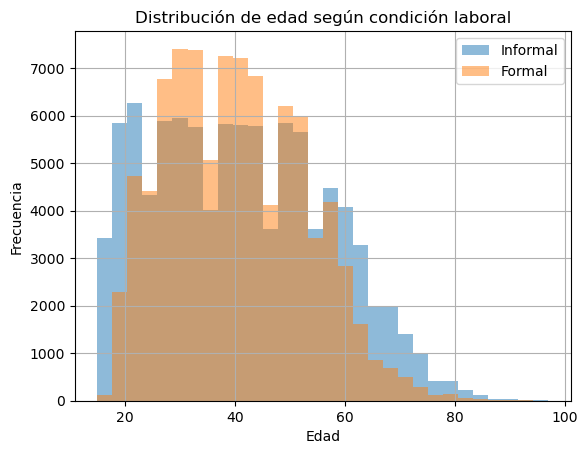

In [137]:
for valor, etiqueta in [(1, "Informal"), (2, "Formal")]:
    df_eda.loc[df_eda["EMP_PPAL"] == valor, "EDA"].hist(
        bins=30,
        alpha=0.5,
        label=etiqueta
    )

plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Distribución de edad según condición laboral")
plt.legend()
plt.show()

La edad promedio es similar entre personas informales y formales, por lo que la media no refleja adecuadamente la relación entre ambas variables. La distribución muestra una mayor presencia de informalidad en edades jóvenes y avanzadas, mientras que la formalidad se concentra más en edades intermedias. Esto confirma que la relación entre edad e informalidad es no lineal y que EDA debe conservarse como variable numérica para que el modelo pueda capturar este comportamiento.

Pasemos a analizar la variable numérica `ANTIGUEDAD`

In [138]:
# describe e hist ya excluyen nan, por ello se muestran 185,835 registros
print(df_eda["ANTIGUEDAD"].describe())

print(
    df_eda.groupby("EMP_PPAL")["ANTIGUEDAD"]
    .describe()
    .round(2)
)

count    185835.000000
mean          8.935620
std           9.935162
min           0.000000
25%           2.000000
50%           5.000000
75%          11.000000
max          86.000000
Name: ANTIGUEDAD, dtype: float64
            count  mean    std  min  25%  50%   75%   max
EMP_PPAL                                                 
1         96099.0  8.64  10.50  0.0  2.0  4.0  11.0  86.0
2         89736.0  9.25   9.28  0.0  2.0  6.0  13.0  76.0


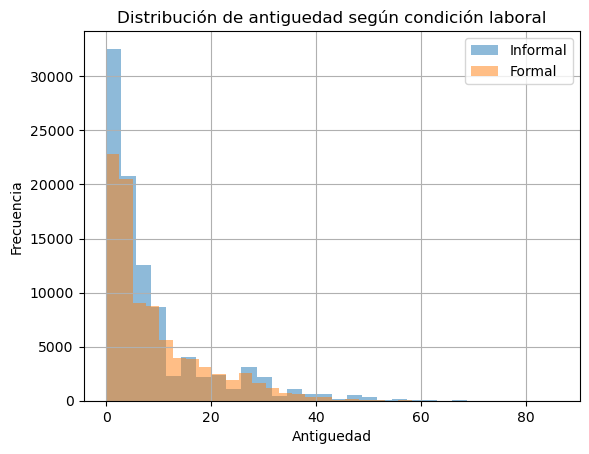

In [139]:
for valor, etiqueta in [(1, "Informal"), (2, "Formal")]:
    df_eda.loc[df_eda["EMP_PPAL"] == valor, "ANTIGUEDAD"].hist(
        bins=30,
        alpha=0.5,
        label=etiqueta
    )

plt.xlabel("Antiguedad")
plt.ylabel("Frecuencia")
plt.title("Distribución de antiguedad según condición laboral")
plt.legend()
plt.show()

La antigüedad laboral presenta una distribución asimétrica, con una fuerte concentración en los primeros años y una cola larga hacia valores altos. Las personas con empleo formal muestran una antigüedad ligeramente mayor que las informales, especialmente en la mediana. Sin embargo, la diferencia global es moderada y la relación no es completamente lineal, por lo que conviene conservar esta variable para que el modelo capture posibles efectos no lineales.

## Antes de comenzar a desarrollar el modelo, haremos una revisión de redundancias y asociaciones entre predictores.

Comenzaremos analizando `EDA`y `ANTIGUEDAD`. Primero, realicemos un diagrama de disperción

Text(0, 0.5, 'Antiguedad (años)')

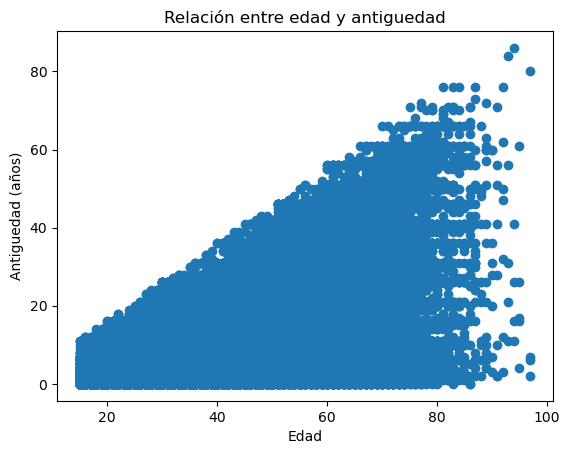

In [140]:
plt.scatter(x=df_eda["EDA"], y=df_eda["ANTIGUEDAD"])
plt.title("Relación entre edad y antiguedad")
plt.xlabel("Edad")
plt.ylabel("Antiguedad (años)")

y su correlacion Pearson y Spearman

In [141]:
df_nona_antiguedad = df_eda.dropna(subset=["ANTIGUEDAD"])

print(stats.pearsonr(x=df_nona_antiguedad["EDA"], y=df_nona_antiguedad["ANTIGUEDAD"]))

corr, p_value = stats.spearmanr(df_nona_antiguedad["EDA"], df_nona_antiguedad["ANTIGUEDAD"])

print(f"Coeficiente de correlacion de Spearman: {corr:.4f}")
print(f"P-value: {p_value:.4e}")

PearsonRResult(statistic=np.float64(0.5458883581239571), pvalue=np.float64(0.0))
Coeficiente de correlacion de Spearman: 0.5210
P-value: 0.0000e+00


Los resultados indican una relación positiva moderada. Los valores

+ Pearson: 0.5459
+ Spearman: 0.5210

muestran que, en general, la antigüedad aumenta con la edad. La similitud entre ambos coeficientes sugiere una tendencia monotónica razonablemente consistente.

La edad representa la etapa de vida, mientras que la antigüedad refleja estabilidad en el empleo actual. No hay evidencia suficiente para eliminar una de las dos por redundancia.

Ahora calcularemos la mediana de `ANTIGUEDAD` por `EDAD_GRUPOò para bservar cómo cambia esta relación entre etapas de vida.

In [142]:
df_nona_antiguedad[["EDAD_GRUPO", "ANTIGUEDAD"]].groupby("EDAD_GRUPO", observed=True).median()

,ANTIGUEDAD
EDAD_GRUPO,
15_a_24,2.0
25_a_34,3.0
35_a_44,6.0
45_a_54,10.0
55_a_64,11.0
65_y_mas,20.0


La antigüedad laboral aumenta progresivamente entre los grupos de edad. Sin embargo, la amplia dispersión observada dentro de cada edad y una correlación moderada indican que ambas variables capturan dimensiones relacionadas, pero distintas. Por ello, se conservarán provisionalmente para evaluar su aporte conjunto durante el modelado.

Investiguemos la relacion entre `EDA`y `ESTADO_CONYUGAL`

In [143]:
df_eda.groupby("ESTADO_CONYUGAL", observed=True)["EDA"].describe()

,count,mean,std,min,25%,50%,75%,max
ESTADO_CONYUGAL,,,,,,,,
casado,68189.0,47.156858,11.991004,16.0,38.00,47.0,55.0,97.0
divorciado,5269.0,48.480736,10.304138,21.0,41.00,49.0,56.0,87.0
no_sabe,22.0,49.500000,11.172884,30.0,42.75,49.0,56.5,73.0
separado,11337.0,44.675928,12.085007,15.0,35.00,44.0,53.0,91.0
soltero,58338.0,31.135298,12.206556,15.0,22.00,28.0,38.0,95.0
union_libre,38964.0,38.855508,11.906387,15.0,30.00,37.0,47.0,97.0
viudo,5438.0,59.401986,12.628659,19.0,51.00,60.0,68.0,97.0


<Axes: xlabel='ESTADO_CONYUGAL', ylabel='EDA'>

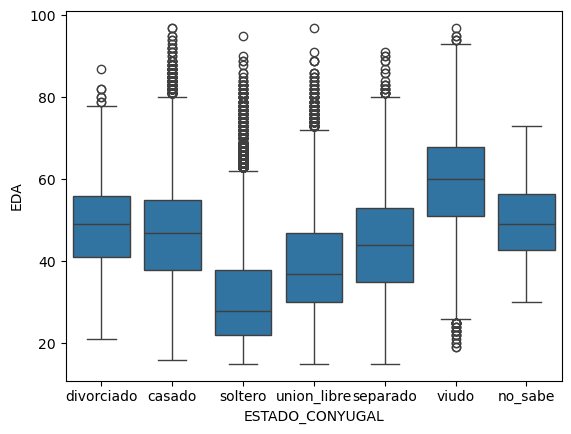

In [144]:
sns.boxplot(data = df_eda, x = "ESTADO_CONYUGAL", y = "EDA")

La edad y el estado conyugal presentan una asociación que se esperada, donde las personas solteras son, en promedio, más jóvenes, mientras que las viudas concentran edades mayores. Sin embargo, existe un solapamiento amplio entre categorías, por lo que ambas variables aportan información relacionada, pero no equivalente. Se conservarán provisionalmente para el modelado.

Comparemos ahora `EDA` frente a `PAR_C_GRUPO`

In [145]:
df_eda.groupby("PAR_C_GRUPO",observed=False)["EDA"].describe()

,count,mean,std,min,25%,50%,75%,max
PAR_C_GRUPO,,,,,,,,
hijo,49570.0,29.456244,9.905162,15.0,22.00,27.0,35.0,77.0
jefe_hogar,86543.0,46.923830,12.780929,15.0,37.00,47.0,56.0,97.0
no_especificado,68.0,37.014706,11.671489,19.0,27.75,35.0,44.0,64.0
no_familiar_otro,1071.0,34.731092,12.893690,15.0,25.00,31.0,42.0,86.0
otro_familiar,15530.0,34.499614,14.320374,15.0,23.00,30.0,43.0,97.0
pareja,34637.0,44.167133,11.700174,15.0,35.00,43.0,52.0,97.0
trabajo_domestico_familia,138.0,40.463768,15.806845,17.0,25.00,42.0,54.0,77.0


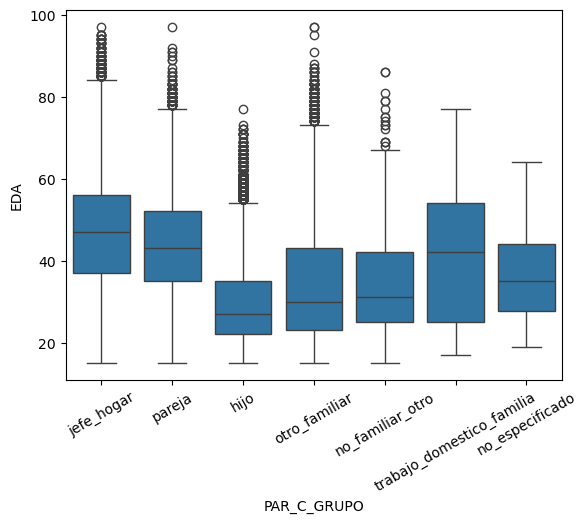

In [146]:
sns.boxplot(data = df_eda, x="PAR_C_GRUPO", y="EDA")
plt.xticks(rotation=30);

La edad se relaciona con la posición dentro del hogar: las personas clasificadas como hijos son considerablemente más jóvenes, mientras que jefes de hogar y parejas presentan edades mayores. Sin embargo, existe un solapamiento amplio entre categorías, por lo que ambas variables capturan información distinta y pueden conservarse provisionalmente.

Con esto, `EDA`, `ESTADO_CONYUGAL` y `PAR_C_GRUPO` pueden mantenerse por ahora. La siguiente comparación sería `INGRESO_GRUPO` frente a `ESCOLARIDAD_GRUPO`.


In [147]:
tabla = pd.crosstab(
    df_eda["ESCOLARIDAD_GRUPO"],
    df_eda["INGRESO_GRUPO"],
    normalize="index"
).round(3)

tabla

INGRESO_GRUPO,hasta_1_sm,mas_1_hasta_2_sm,mas_2_hasta_3_sm,mas_3_hasta_5_sm,mas_5_sm,no_especificado,sin_ingresos
ESCOLARIDAD_GRUPO,,,,,,,
media_superior,0.474,0.329,0.050,0.014,0.004,0.095,0.034
no_sabe,0.443,0.272,0.048,0.031,0.009,0.175,0.022
normal_tecnica,0.413,0.365,0.068,0.019,0.006,0.105,0.023
posgrado,0.121,0.357,0.178,0.122,0.050,0.168,0.004
preescolar,0.624,0.151,0.032,0.000,0.000,0.054,0.140
primaria,0.614,0.225,0.022,0.007,0.002,0.063,0.066
profesional,0.278,0.382,0.115,0.047,0.013,0.144,0.021
secundaria,0.548,0.294,0.034,0.009,0.002,0.075,0.039
sin_escolaridad,0.670,0.133,0.012,0.004,0.002,0.048,0.131


Para más claridad, observemos esta tabla en un mapa de calor

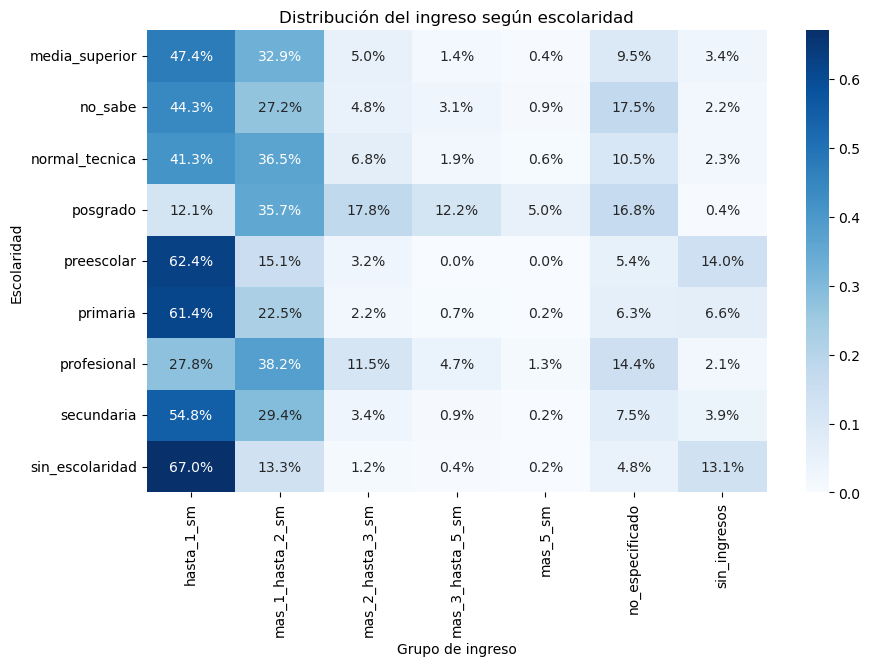

In [148]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    tabla,
    annot=True,
    fmt=".1%",
    cmap="Blues"
)

plt.xlabel("Grupo de ingreso")
plt.ylabel("Escolaridad")
plt.title("Distribución del ingreso según escolaridad")
plt.show()

In [149]:
tabla_conteos = pd.crosstab(
    df_eda["ESCOLARIDAD_GRUPO"],
    df_eda["INGRESO_GRUPO"]
)

chi2, p_value, _, _ = stats.chi2_contingency(tabla_conteos)

n = tabla_conteos.to_numpy().sum()
k = min(tabla_conteos.shape)
cramer_v = np.sqrt(chi2 / (n * (k - 1)))

print(f"Chi-cuadrado: {chi2:.2f}")
print(f"P-value: {p_value:.4e}")
print(f"V de Cramér: {cramer_v:.4f}")

Chi-cuadrado: 24465.34
P-value: 0.0000e+00
V de Cramér: 0.1474


La escolaridad y el ingreso presentan una asociación estadísticamente significativa, pero de magnitud baja a moderada (`V de Cramér = 0.1474`). La escolaridad superior se relaciona con mayores niveles de ingreso, aunque existe una amplia variabilidad dentro de cada nivel educativo. Por ello, ambas variables aportan información distinta y se conservarán provisionalmente.

La siguiente comparación la haremos entre `ENTIDAD` frente a `TAMANO_LOCALIDAD`.


In [150]:
tabla_conteos = pd.crosstab(
    df_eda["ENTIDAD"],
    df_eda["TAMANO_LOCALIDAD"]
)

chi2, p_value, _, _ = stats.chi2_contingency(tabla_conteos)

n = tabla_conteos.to_numpy().sum()
k = min(tabla_conteos.shape)
cramer_v = np.sqrt(chi2 / (n * (k - 1)))

print(f"Chi-cuadrado: {chi2:.2f}")
print(f"P-value: {p_value:.4e}")
print(f"V de Cramér: {cramer_v:.4f}")

Chi-cuadrado: 39624.82
P-value: 0.0000e+00
V de Cramér: 0.2654


La entidad federativa y el tamaño de localidad presentan una asociación moderada (`V de Cramér = 0.2654`). La composición urbana y rural cambia de forma importante entre entidades, pero ambas variables representan dimensiones distintas del contexto territorial. Por ello, se conservarán provisionalmente para el modelado.

Con esto cerramos la revisión inicial de redundancias. No aparece ninguna relación lo bastante fuerte como para justificar eliminar variables en esta etapa.



## Validación del conjunto a utilizar
Creemos un nuevo dataframe con las variables a utilizar (eliminaremos EDAD_GRUPO y ANTIGUEDAD_GRUPO), validemos sus tipos de datos y el número de nulos por columna

In [151]:
variables_finales = [
    "EDA",
    "ANTIGUEDAD",
    "PAR_C_GRUPO",
    "ESCOLARIDAD_GRUPO",
    "INGRESO_GRUPO",
    "DURACION_GRUPO",
    "TAMANO_LOCALIDAD",
    "ESTADO_CONYUGAL",
    "BUSQUEDA_OTRO_EMPLEO",
    "TIENE_JEFE",
    "SEXO",
    "ENTIDAD"
]

X_modelo = df_eda[variables_finales].copy()
y = df_eda["EMP_PPAL"].copy()
pesos = df_eda["FAC_TRI"].copy()


print("Forma del dataframe \n",X_modelo.shape)
print("Tipos de datos para las columnas del dataframe \n",X_modelo.dtypes)
print("Número de valores nulos para cada columna \n",X_modelo.isna().sum())

Forma del dataframe 
 (187557, 12)
Tipos de datos para las columnas del dataframe 
 EDA                       int64
ANTIGUEDAD              float64
PAR_C_GRUPO              object
ESCOLARIDAD_GRUPO        object
INGRESO_GRUPO            object
DURACION_GRUPO           object
TAMANO_LOCALIDAD         object
ESTADO_CONYUGAL          object
BUSQUEDA_OTRO_EMPLEO     object
TIENE_JEFE               object
SEXO                     object
ENTIDAD                  object
dtype: object
Número de valores nulos para cada columna 
 EDA                        0
ANTIGUEDAD              1722
PAR_C_GRUPO                0
ESCOLARIDAD_GRUPO          0
INGRESO_GRUPO              0
DURACION_GRUPO             0
TAMANO_LOCALIDAD           0
ESTADO_CONYUGAL            0
BUSQUEDA_OTRO_EMPLEO       0
TIENE_JEFE                 0
SEXO                       0
ENTIDAD                    0
dtype: int64


Correcto. Los únicos valores nulos que existen corresponden a la columna ANTIGUEDAD. Sus faltantes corresponden al 0.92% de la muestra, son personas válidas y la pérdida sería innecesaria. Los imputaremos al conjunto de entrenamiento más adelante.

Actualmente la columna objetivo EMP_PPAL tiene valores 1, 2. La convertiremos a 0, 1; donde 1 representará la informalidad, que es el evento de interés

In [152]:
y = df_eda["EMP_PPAL"].map({1: 1, 2: 0})
y.value_counts()

EMP_PPAL
1    97079
0    90478
Name: count, dtype: int64

**Con esto damos el cierre de la actual notebook. Se completó la preparación del conjunto de datos para modelado. Se seleccionaron 12 predictores finales, se revisaron posibles redundancias entre variables, se recodificó EMP_PPAL como variable binaria (1 = informal, 0 = formal) y se conservaron los factores de expansión FAC_TRI. El conjunto resultante queda listo para iniciar la etapa de modelado, manteniendo los valores faltantes de ANTIGUEDAD para ser tratados posteriormente dentro del pipeline de entrenamiento.**

In [167]:
df_modelado_final = X_modelo.copy()
df_modelado_final["EMP_PPAL"] = y
df_modelado_final["FAC_TRI"] = pesos

df_modelado_final.to_csv("/home/jeffrey/Documentos/Proyectos/enoe_informalidad/data/processed/df_modelado_final.csv",index=False)